In [292]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [293]:
# Building model
model = nn.Sequential(
    nn.Linear(1,1),  # input layer
    nn.ReLU(),       # activation function
    nn.Linear(1,1)   # output layer
    )

model

Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1, out_features=1, bias=True)
)

In [294]:
# Function to build and train the model
def build_and_train_model(model, x, y, epochs, learning_rate):
    # loss function
    loss_fun = nn.MSELoss()
    
    # optimizer
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    
    # train the model
    losses = torch.zeros(epochs)
    
    for epochi in range(epochs):
        # forward pass
        y_predict = model(x)
        
        # compute loss
        loss = loss_fun(y_predict,y)
        losses[epochi] = loss
        
        # backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    # Compute model prediction
    final_predictions = model(x)
    
    return losses, final_predictions

In [295]:
def Create_data(m):
    N = 50
    x = torch.randn(N,1)
    y = m * x + torch.randn(N,1)/2
    return x,y

In [296]:
# Meta parameters
learning_rate = 0.05
epochs = 500
x, y = Create_data(m=0.5) 



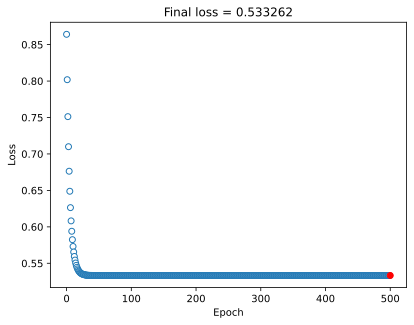

In [297]:
# show the losses

# manually compute losses
# final forward pass
losses, predictions = build_and_train_model(model, x, y, epochs, learning_rate)
# final loss (MSE)
testloss = (predictions-y).pow(2).mean()

plt.plot(losses.detach(),'o',markerfacecolor='w',linewidth=.1)
plt.plot(epochs,testloss.detach(),'ro')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Final loss = %g' %testloss.item())
plt.show()

In [298]:
# Detach the loss to get a scalar value: That is getting only the value(number). we could also use .item() instead of .detach() to get the same result.
testloss.detach()

tensor(0.5333)

c:\Users\ekein\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\ekein\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


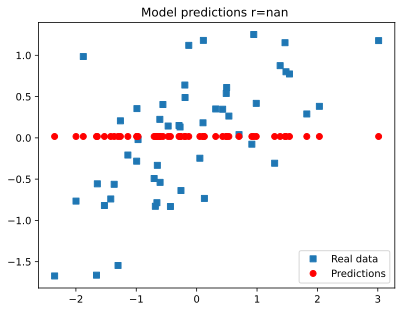

In [299]:
# Plot the model predictions
plt.plot(x,y,'s',label='Real data')
plt.plot(x,predictions.detach(),'ro',label='Predictions')
plt.title(f'Model predictions r={np.corrcoef(y.T, predictions.detach().T)[0,1]:.2f} ')
plt.legend()
plt.show()

In [ ]:
# The slope to simulate
slopes = np.linspace(-2,2,21)
numExps = 50

# Initialize the output matrix
results = np.zeros((len(slopes), numExps, 2))

for i, slope in enumerate(slopes):
    for j in range(numExps):
        # Create data
        x, y = Create_data(m=slope)
        
        # Build and train the model
        losses, predictions = build_and_train_model(model, x, y, epochs, learning_rate)
        
        # Compute final loss and correlation coefficient
        final_loss = losses[-1] # Get the final loss as a scalar
        r_value = np.corrcoef(y.T, predictions.detach().T)[0,1]
        
        # Store results
        results[i, j] = [final_loss, r_value]

results[np.isnan(results)] = 0



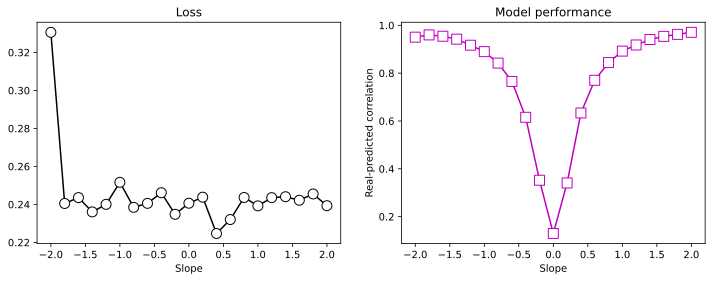

In [301]:
# plot the results!

fig,ax = plt.subplots(1,2,figsize=(12,4))

ax[0].plot(slopes,np.mean(results[:,:,0],axis=1),'ko-',markerfacecolor='w',markersize=10)
ax[0].set_xlabel('Slope')
ax[0].set_title('Loss')

ax[1].plot(slopes,np.mean(results[:,:,1],axis=1),'ms-',markerfacecolor='w',markersize=10)
ax[1].set_xlabel('Slope')
ax[1].set_ylabel('Real-predicted correlation')
ax[1].set_title('Model performance')

plt.show()